# Session 4 - Ensemble Models and Hyper-parameter Optimisation

**Course:** Machine Learning in Geoscience - A Project-Based Course  
**Project:** Wind-speed forecasting at Abali  
**Session length:** 90 minutes  
**Data source (the only one used):** `data/raw/abali.xlsx`

---

## Learning objectives

By the end of this session you will be able to:

1. Explain the difference between **bagging** (random forest) and **boosting** (XGBoost, LightGBM) and what each one does to the bias-variance trade-off.
2. Name the hyper-parameters of a gradient-boosting model and predict what each one does before you change it.
3. Build a **time-aware cross-validation** scheme (`TimeSeriesSplit` with a gap) and explain why the default `cross_val_score` on shuffled folds is invalid here.
4. Run a **randomised hyper-parameter search** inside the training block, and read its results honestly (including the risk of over-tuning to the validation block).
5. Apply one tuned configuration to all four horizons and compare it fairly with the classical models from Session 3.
6. Account for the **cost** of a model - the cheapest model that beats the baseline is often the professional choice.

## Prerequisites

Sessions 1-3. The helpers for loading, feature building and splitting are repeated below, unchanged.

---

## 1. Setup

`data/raw/abali.xlsx` is read and cleaned **in memory**; nothing is written to disk. The model families from Session 3 come back with identical settings, so that every comparison in this session is internally fair.

In [1]:
# ---------------------------------------------------------------------------
# Session 4 setup (self-contained)
# ---------------------------------------------------------------------------
import os
import sys
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 80)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 4)

QUICK_MODE = True              # True: smaller models and a shorter search (classroom run)
N_TREES = 80 if QUICK_MODE else 300
N_JOBS = 2                     # joblib spawns one worker per job: keep this small on a laptop
N_SEARCH_ITER = 8 if QUICK_MODE else 40
CV_SPLITS = 3 if QUICK_MODE else 4
HORIZONS = [3, 6, 12, 24]

# --- optional boosted-tree libraries -----------------------------------------
HAS_XGB = False
try:
    import xgboost
    HAS_XGB = True
    XGB_VERSION = xgboost.__version__
except Exception as exc:
    XGB_VERSION = 'not installed'
    print('[optional] xgboost not available:', exc)
    print('           install with:  pip install xgboost')

HAS_LGBM = False
try:
    import lightgbm
    HAS_LGBM = True
    LGBM_VERSION = lightgbm.__version__
except Exception as exc:
    LGBM_VERSION = 'not installed'
    print('[optional] lightgbm not available:', exc)
    print('           install with:  pip install lightgbm')

if not (HAS_XGB or HAS_LGBM):
    print()
    print('[fallback] no boosted-tree library found: this session uses sklearn')
    print('           GradientBoostingRegressor, which is slower but equivalent in idea.')

# --- data path (relative; works from the repo root or from course/notebooks) --
RAW_CANDIDATES = ['data/raw/abali.xlsx', '../data/raw/abali.xlsx', '../../data/raw/abali.xlsx']


def resolve_raw_path(candidates=RAW_CANDIDATES):
    '''Return the first existing relative path to the Abali raw data file.'''
    for candidate in candidates:
        if os.path.exists(candidate):
            print('using raw data file:', candidate)
            return candidate
    raise FileNotFoundError('Could not find abali.xlsx. Expected at ' + candidates[0] +
                            ' relative to the repository root.')


RAW_PATH = resolve_raw_path()
COL_MAP = {'DateTimes': 'datetime', 'Wind Speed(m/s)': 'wind_speed_ms',
           'Wind Direction(D)': 'wind_direction_deg', 'Air Pressure(hPa)': 'pressure_hpa',
           'Air Temperature(C)': 'temperature_c', 'rel. Humidity(%)': 'humidity'}
DATA_COLS = ['wind_speed_ms', 'wind_direction_deg', 'pressure_hpa', 'temperature_c', 'humidity']
PHYSICAL_BOUNDS = {'wind_speed_ms': (0.0, 60.0), 'wind_direction_deg': (0.0, 360.0),
                   'pressure_hpa': (500.0, 1100.0), 'temperature_c': (-60.0, 60.0),
                   'humidity': (0.0, 100.0)}

print()
print('Python:', sys.version.split()[0], '| pandas:', pd.__version__)
print('xgboost:', XGB_VERSION, '| lightgbm:', LGBM_VERSION)
print('QUICK_MODE:', QUICK_MODE, '| N_JOBS:', N_JOBS, '| search iterations:', N_SEARCH_ITER, '| CV folds:', CV_SPLITS)

using raw data file: ../../data/raw/abali.xlsx

Python: 3.13.7 | pandas: 2.3.2
xgboost: 3.2.0 | lightgbm: 4.7.0
QUICK_MODE: True | N_JOBS: 2 | search iterations: 8 | CV folds: 3


In [2]:
# --- data helpers, identical to Sessions 1-3 --------------------------------
def load_abali_hourly(path=RAW_PATH, verbose=False):
    """Raw Abali Excel -> clean hourly DataFrame, entirely in memory."""
    if not os.path.exists(path):
        raise FileNotFoundError('Could not find ' + path + ' - run from the repository root.')
    raw = pd.read_excel(path)[list(COL_MAP)].rename(columns=COL_MAP)
    raw['datetime'] = pd.to_datetime(raw['datetime'], errors='coerce')
    for c in DATA_COLS:
        raw[c] = pd.to_numeric(raw[c], errors='coerce')
    raw[DATA_COLS] = raw[DATA_COLS].mask(raw[DATA_COLS] <= -900)
    for c, (lo, hi) in PHYSICAL_BOUNDS.items():
        raw[c] = raw[c].mask((raw[c] < lo) | (raw[c] > hi))
    raw = raw.dropna(subset=['datetime'])
    raw = raw.sort_values('datetime').drop_duplicates(subset=['datetime'], keep='first')
    g = raw.set_index('datetime')
    hourly = g[DATA_COLS].resample('1h').mean()
    n_obs = g['wind_speed_ms'].resample('1h').count()
    grid = pd.date_range(hourly.index.min(), hourly.index.max(), freq='h')
    hourly = hourly.reindex(grid)
    hourly['n_obs'] = n_obs.reindex(grid).fillna(0).astype(int)
    hourly.index.name = 'datetime'
    aux = [c for c in DATA_COLS if c != 'wind_speed_ms']
    hourly[aux] = hourly[aux].interpolate(method='linear', limit=2, limit_area='inside')
    if verbose:
        print('hourly rows:', len(hourly), '| range:', hourly.index.min(), '->', hourly.index.max())
    return hourly


def build_horizon_dataset(hourly, horizon, lags=(1, 2, 3, 6, 12, 24), windows=(3, 6, 24)):
    """Leakage-safe features at T, target at T+horizon."""
    df = hourly.copy()
    rad = np.radians(df['wind_direction_deg'])
    df['wind_dir_sin'] = np.sin(rad)
    df['wind_dir_cos'] = np.cos(rad)
    df = df.drop(columns=['wind_direction_deg', 'n_obs'])
    base = ['wind_speed_ms', 'pressure_hpa', 'temperature_c', 'humidity', 'wind_dir_sin', 'wind_dir_cos']
    angular = ['wind_dir_sin', 'wind_dir_cos']
    df['target'] = df['wind_speed_ms'].shift(-horizon)
    features = list(base)
    for c in base:
        for k in lags:
            df[c + '_lag' + str(k)] = df[c].shift(k)
            features.append(c + '_lag' + str(k))
    for c in base:
        past = df[c].shift(1)
        for w in windows:
            df[c + '_roll' + str(w) + '_mean'] = past.rolling(w).mean()
            features.append(c + '_roll' + str(w) + '_mean')
            if c not in angular:
                df[c + '_roll' + str(w) + '_max'] = past.rolling(w).max()
                features.append(c + '_roll' + str(w) + '_max')
                df[c + '_roll' + str(w) + '_std'] = past.rolling(w).std()
                features.append(c + '_roll' + str(w) + '_std')
    idx = df.index
    df['hour'] = idx.hour
    df['dayofyear'] = idx.dayofyear
    df['month'] = idx.month
    df['dayofweek'] = idx.dayofweek
    df['is_weekend'] = (idx.dayofweek >= 5).astype(int)
    df['hour_sin'] = np.sin(2 * np.pi * idx.hour / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * idx.hour / 24.0)
    df['doy_sin'] = np.sin(2 * np.pi * idx.dayofyear / 365.25)
    df['doy_cos'] = np.cos(2 * np.pi * idx.dayofyear / 365.25)
    features += ['hour', 'dayofyear', 'month', 'dayofweek', 'is_weekend', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']
    valid = df[features].notna().all(axis=1) & df['target'].notna()
    X = df.loc[valid, features].copy()
    y = df.loc[valid, 'target'].copy()
    X.index.name = 'origin_time'
    return X, y


def chronological_split(n, frac=(0.70, 0.15, 0.15), gap=0):
    """Train / validation / test indices with a purge gap of `gap` rows."""
    n_train, n_val = int(frac[0] * n), int(frac[1] * n)
    return (np.arange(0, max(n_train - gap, 1)),
            np.arange(n_train + gap, max(n_train + n_val - gap, 1)),
            np.arange(n_train + n_val + gap, n))


def select_features(X_train, y_train, min_std=1e-8, max_pair_corr=0.98, verbose=False):
    """Training-only filtering: drop near-constant and near-duplicate columns."""
    keep = [c for c in X_train.columns if X_train[c].std() > min_std]
    corr = X_train[keep].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    target_corr = X_train[keep].apply(lambda col: abs(np.corrcoef(col.values, y_train.values)[0, 1]))
    dropped = []
    for col in upper.columns:
        for p in upper.index[upper[col] > max_pair_corr].tolist():
            weaker = col if target_corr[col] < target_corr[p] else p
            if weaker not in dropped and weaker in keep:
                dropped.append(weaker)
    keep = [c for c in keep if c not in dropped]
    if verbose:
        print('kept', len(keep), 'of', X_train.shape[1], 'features')
    return keep


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def metrics(y_true, y_pred):
    """MAE, MSE, RMSE and R2 for one block."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(y_true, y_pred)
    return {'MAE': float(mean_absolute_error(y_true, y_pred)), 'MSE': float(mse),
            'RMSE': float(np.sqrt(mse)), 'R2': float(r2_score(y_true, y_pred))}


def diurnal_climatology(hourly, horizon, train_origin_times, origin_times):
    """Training-period mean wind speed for the hour of the TARGET time (T + H)."""
    window = hourly['wind_speed_ms'].loc[train_origin_times.min():train_origin_times.max() + pd.Timedelta(hours=horizon)]
    by_hour = window.groupby(window.index.hour).mean().to_dict()
    target_hour = (pd.DatetimeIndex(origin_times) + pd.Timedelta(hours=horizon)).hour
    return np.array([by_hour[h] for h in target_hour])


hourly = load_abali_hourly(verbose=True)
DATA = {}
for H in HORIZONS:
    X, y = build_horizon_dataset(hourly, H)
    tr, va, te = chronological_split(len(y), gap=H)
    cols = select_features(X.iloc[tr], y.iloc[tr])
    DATA[H] = {'X_train': X.iloc[tr][cols], 'y_train': y.iloc[tr],
               'X_val': X.iloc[va][cols], 'y_val': y.iloc[va],
               'X_test': X.iloc[te][cols], 'y_test': y.iloc[te], 'features': cols}

print()
for H in HORIZONS:
    d = DATA[H]
    print('H = {:>2d} h | features {:>3d} | train {:>5d} | val {:>4d} | test {:>4d} | train {} .. {} | val {} .. {}'.format(
        H, len(d['features']), len(d['y_train']), len(d['y_val']), len(d['y_test']),
        d['X_train'].index[0].date(), d['X_train'].index[-1].date(),
        d['X_val'].index[0].date(), d['X_val'].index[-1].date()))
print()
print('the TEST block is built but stays untouched in this session')

hourly rows: 10440 | range: 2024-01-01 00:00:00 -> 2025-03-10 23:00:00

H =  3 h | features  74 | train  6027 | val 1286 | test 1290 | train 2024-01-02 .. 2024-10-20 | val 2024-10-21 .. 2024-12-28
H =  6 h | features  72 | train  6017 | val 1278 | test 1286 | train 2024-01-02 .. 2024-10-20 | val 2024-10-21 .. 2024-12-28
H = 12 h | features  72 | train  5998 | val 1263 | test 1277 | train 2024-01-02 .. 2024-10-20 | val 2024-10-21 .. 2024-12-27
H = 24 h | features  72 | train  5963 | val 1234 | test 1260 | train 2024-01-02 .. 2024-10-19 | val 2024-10-21 .. 2024-12-26

the TEST block is built but stays untouched in this session


---

## 2. From a forest to a boosted ensemble

Both model families are *ensembles of decision trees*, but they combine them in opposite ways.

| | **Bagging** - random forest | **Boosting** - XGBoost, LightGBM |
|---|---|---|
| How trees are built | independently, on bootstrap samples | sequentially, each tree fits the **residual errors** of the previous ensemble |
| Tree size | deep, low bias, high variance | shallow (`max_depth` 3-8), **high bias, low variance** |
| Combination | simple average | weighted sum with a learning rate |
| Effect on error | reduces **variance** | reduces **bias** |
| Main risk | overfitting the training block; cannot extrapolate | overfitting if you boost for too many rounds; also cannot extrapolate |
| Typical strength | robust with no tuning | state of the art on tabular data, but needs tuning |

### Why boosting usually wins on tabular meteorological data

Wind speed depends on *interactions* that are not additive: a strong pressure gradient only produces strong wind when the stability and the direction are favourable too. Boosting builds those interactions one small tree at a time and stops when the validation error stops improving. That is why, on small-to-medium tabular datasets like ours, gradient boosting frequently beats a random forest - and why the tuning of three or four hyper-parameters matters more than the choice between XGBoost and LightGBM.

### The hyper-parameters worth understanding

| Hyper-parameter | What it controls | If you increase it |
|---|---|---|
| `n_estimators` | number of boosting rounds (trees) | less bias, more overfitting risk, longer training |
| `learning_rate` | how much each tree contributes | faster learning, but each round is more aggressive - usually pair a larger rate with fewer rounds |
| `max_depth` (XGBoost) / `num_leaves` (LightGBM) | complexity of each tree | more interactions captured, more variance |
| `subsample` | fraction of rows per tree | more randomness, less overfitting |
| `colsample_bytree` | fraction of features per tree | same, and lower memory |
| `min_child_weight` / `min_child_samples` | minimum evidence for a split | smoother, more conservative trees |
| `reg_lambda` / `reg_alpha` | L2 / L1 penalty on leaf weights | shrinks extreme leaf values |

**Check for understanding:** you increase `n_estimators` from 100 to 1000 with `learning_rate = 0.3` and the validation error gets worse. Diagnose in one sentence. *The model has started to fit noise in the training block (and the aggressive learning rate makes each round over-commit); reduce the learning rate, add subsampling, or stop earlier using the validation curve.*

---

## 3. Reference points for the comparison

We cannot judge a tuned ensemble without a reference. Three numbers are needed per horizon:

1. **persistence** - the operational benchmark;
2. **diurnal climatology** - the physical benchmark, and the hardest one to beat at 24 h;
3. **random forest** with the Session 3 settings - the classical-ML benchmark.

They are recomputed here rather than copied, so that this session is self-consistent.

In [3]:
from sklearn.ensemble import RandomForestRegressor


def fit_predict(model, D, name):
    """Fit on the training block, return validation predictions and timing."""
    t0 = time.time()
    model.fit(D['X_train'], D['y_train'])
    fit_seconds = time.time() - t0
    pred = model.predict(D['X_val'])
    result = {'pred': pred, 'metrics': metrics(D['y_val'], pred), 'fit_seconds': fit_seconds, 'name': name}
    del model                              # keep peak memory flat
    return result


REFERENCE = {}
for H in HORIZONS:
    D = DATA[H]
    ref = {}
    ref['Persistence'] = {'pred': D['X_val']['wind_speed_ms'].values, 'fit_seconds': 0.0, 'name': 'Persistence'}
    ref['Persistence']['metrics'] = metrics(D['y_val'], ref['Persistence']['pred'])

    clim = diurnal_climatology(hourly, H, D['X_train'].index, D['X_val'].index)
    ref['Diurnal climatology'] = {'pred': clim, 'fit_seconds': 0.0, 'name': 'Diurnal climatology',
                                  'metrics': metrics(D['y_val'], clim)}

    rf = RandomForestRegressor(n_estimators=N_TREES, max_features='sqrt', min_samples_leaf=2,
                               random_state=SEED, n_jobs=N_JOBS)
    ref['Random Forest'] = fit_predict(rf, D, 'Random Forest')
    REFERENCE[H] = ref

print('reference models, validation block:')
for H in HORIZONS:
    print('--- H = {} h'.format(H))
    for name, r in REFERENCE[H].items():
        m = r['metrics']
        print('  {:<20s} MAE = {:.4f}  RMSE = {:.4f}  R2 = {:+.4f}  ({:.1f} s)'.format(
            name, m['MAE'], m['RMSE'], m['R2'], r['fit_seconds']))
print()
print('Note how good the diurnal climatology is: it is a one-line physical model.')
print('Any tuned ensemble that fails to beat it at some horizon has not earned its') 
print('complexity at that horizon, and you should say so in the report.')

C:\Users\Amir\AppData\Local\Temp\ipykernel_8664\424769286.py:112: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  window = hourly['wind_speed_ms'].loc[train_origin_times.min():train_origin_times.max() + pd.Timedelta(hours=horizon)]
C:\Users\Amir\AppData\Local\Temp\ipykernel_8664\424769286.py:114: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  target_hour = (pd.DatetimeIndex(origin_times) + pd.Timedelta(hours=horizon)).hour
C:\Users\Amir\AppData\Local\Temp\ipykernel_8664\424769286.py:112: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+

reference models, validation block:
--- H = 3 h
  Persistence          MAE = 1.1200  RMSE = 1.6163  R2 = +0.0015  (0.0 s)
  Diurnal climatology  MAE = 1.5142  RMSE = 1.7998  R2 = -0.2381  (0.0 s)
  Random Forest        MAE = 1.0029  RMSE = 1.3618  R2 = +0.2912  (2.1 s)
--- H = 6 h
  Persistence          MAE = 1.4952  RMSE = 2.0453  R2 = -0.6037  (0.0 s)
  Diurnal climatology  MAE = 1.5150  RMSE = 1.8019  R2 = -0.2448  (0.0 s)
  Random Forest        MAE = 1.3523  RMSE = 1.6813  R2 = -0.0837  (2.3 s)
--- H = 12 h
  Persistence          MAE = 1.7469  RMSE = 2.3787  R2 = -0.9511  (0.0 s)
  Diurnal climatology  MAE = 1.5461  RMSE = 1.8656  R2 = -0.2001  (0.0 s)
  Random Forest        MAE = 1.3115  RMSE = 1.6979  R2 = +0.0058  (2.3 s)
--- H = 24 h
  Persistence          MAE = 1.3711  RMSE = 2.3781  R2 = -0.2149  (0.0 s)
  Diurnal climatology  MAE = 1.6677  RMSE = 2.2566  R2 = -0.0939  (0.0 s)
  Random Forest        MAE = 1.4142  RMSE = 2.1528  R2 = +0.0045  (2.5 s)

Note how good the diurnal

---

## 4. Time-aware cross-validation

A single train/validation split gives one number that depends on which winter you happened to hold out. To tune a model we need several honest folds - and there is only one correct way to build them for time series.

```
TimeSeriesSplit(n_splits=3, gap=6) on the TRAINING block:

fold 1:  [====== train ======] <<gap>> [val]
fold 2:  [========= train =========] <<gap>> [val]
fold 3:  [============ train ============] <<gap>> [val]
```

Properties that matter:

- **expanding window**: every fold trains on *past* data only, never on the future;
- **gap**: `gap = H` rows are dropped between the training part and the validation part of each fold, exactly as in our main split, because a training row at `T` carries a target at `T+H`;
- **inside the training block only**: the official validation and test blocks stay out of the tuning loop.

**Never do this:**

```python
# WRONG: shuffled folds on time-series data
cross_val_score(model, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=0))
```

Each fold then contains rows adjacent in time to its own validation rows, so the score is optimistic in the same way as the shuffled split in Session 2. `TimeSeriesSplit` is the only fold generator we use, everywhere.

The cell below visualises the folds and reports, for one horizon, the per-fold validation MAE of a default boosting model. The **spread between folds** is itself a result: it tells you how much your score depends on the year you happened to sample.

fold geometry for H = 6 h (training block has 6017 rows):
 fold  train_rows  val_rows train_from   train_to   val_from     val_to  gap_hours
    1        1499      1504 2024-01-02 2024-04-01 2024-04-02 2024-06-09          7
    2        3003      1504 2024-01-02 2024-06-09 2024-06-09 2024-08-16          7
    3        4507      1504 2024-01-02 2024-08-16 2024-08-16 2024-10-20          7


C:\Users\Amir\AppData\Local\Temp\ipykernel_8664\861369650.py:14: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  'gap_hours': int((X_tr.index[i_va[0]] - X_tr.index[i_tr[-1]]) / pd.Timedelta(hours=1))})


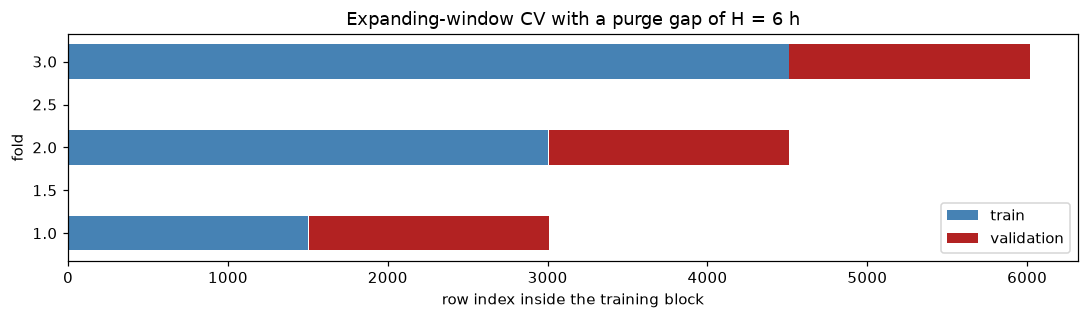


per-fold validation MAE of the default booster (H = 6 h): ['1.765', '1.448', '1.197']
mean 1.470 m/s | spread 0.568 m/s | ratio max/min 1.47

A spread of a few tenths of a m/s is normal for seasonal data. It means that
differences of less than about 0.1 m/s between two models are NOT real: they
are noise from the particular months inside each fold. Report that uncertainty.


In [4]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

H_CV = 6
D = DATA[H_CV]
X_tr, y_tr = D['X_train'], D['y_train']
cv = TimeSeriesSplit(n_splits=CV_SPLITS, gap=H_CV)

print('fold geometry for H = {} h (training block has {} rows):'.format(H_CV, len(y_tr)))
rows = []
for k, (i_tr, i_va) in enumerate(cv.split(X_tr), start=1):
    rows.append({'fold': k, 'train_rows': len(i_tr), 'val_rows': len(i_va),
                 'train_from': X_tr.index[i_tr[0]].date(), 'train_to': X_tr.index[i_tr[-1]].date(),
                 'val_from': X_tr.index[i_va[0]].date(), 'val_to': X_tr.index[i_va[-1]].date(),
                 'gap_hours': int((X_tr.index[i_va[0]] - X_tr.index[i_tr[-1]]) / pd.Timedelta(hours=1))})
print(pd.DataFrame(rows).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 3))
for k, (i_tr, i_va) in enumerate(cv.split(X_tr), start=1):
    ax.barh(k, len(i_tr), left=0, color='steelblue', height=0.4, label='train' if k == 1 else None)
    ax.barh(k, len(i_va), left=len(i_tr) + H_CV, color='firebrick', height=0.4, label='validation' if k == 1 else None)
ax.set_xlabel('row index inside the training block')
ax.set_ylabel('fold')
ax.set_title('Expanding-window CV with a purge gap of H = {} h'.format(H_CV))
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# How stable is a default boosted model across folds?
def default_booster():
    if HAS_LGBM:
        return lightgbm.LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=31,
                                      random_state=SEED, n_jobs=N_JOBS, verbose=-1)
    if HAS_XGB:
        return xgboost.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5,
                                    random_state=SEED, n_jobs=N_JOBS, verbosity=0)
    from sklearn.ensemble import GradientBoostingRegressor
    return GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=SEED)


fold_mae = []
for k, (i_tr, i_va) in enumerate(cv.split(X_tr), start=1):
    model = default_booster()
    model.fit(X_tr.iloc[i_tr], y_tr.iloc[i_tr])
    fold_mae.append(metrics(y_tr.iloc[i_va], model.predict(X_tr.iloc[i_va]))['MAE'])
    del model
print()
print('per-fold validation MAE of the default booster (H = {} h): {}'.format(
    H_CV, ['{:.3f}'.format(v) for v in fold_mae]))
print('mean {:.3f} m/s | spread {:.3f} m/s | ratio max/min {:.2f}'.format(
    float(np.mean(fold_mae)), float(np.max(fold_mae) - np.min(fold_mae)),
    float(np.max(fold_mae) / np.min(fold_mae))))
print()
print('A spread of a few tenths of a m/s is normal for seasonal data. It means that')
print('differences of less than about 0.1 m/s between two models are NOT real: they')
print('are noise from the particular months inside each fold. Report that uncertainty.')

---

## 5. Hyper-parameter tuning, done honestly

### The search space

We tune only the parameters that matter, with **log-uniform** sampling where the effect is multiplicative:

| Parameter | Candidates | Why this range |
|---|---|---|
| `n_estimators` | 200, 400, 800 | enough rounds for a small learning rate; more rounds always cost time |
| `learning_rate` | 0.02, 0.05, 0.1, 0.2 | below 0.02 training becomes slow; above 0.2 overfits quickly |
| `max_depth` / `num_leaves` | 3, 5, 8 / 15, 31, 63 | the interaction depth the physics plausibly needs |
| `subsample` | 0.6, 0.8, 1.0 | row randomness as regularisation |
| `colsample_bytree` | 0.6, 0.8, 1.0 | feature randomness; also cuts memory |
| `min_child_weight` / `min_child_samples` | 1, 5, 20 | minimum evidence per leaf |
| `reg_lambda` | 0, 1, 10 | shrinks aggressive leaf values |

### The protocol

1. Search **inside the training block** with `TimeSeriesSplit(gap=H)`.
2. Score with `neg_mean_absolute_error`, because MAE in m/s is the metric we will report.
3. Use `RandomizedSearchCV`, not an exhaustive grid: with 7 parameters a full grid is impossible and most of it is uninformative.
4. Take the best configuration and **verify it on the official validation block** - the fold score is a *selection* criterion, not a result.
5. Report the top candidates, not just the winner. If the top five are within noise, say that the tuning has saturated.

### The trap: tuning on the validation block

Every time you look at the validation MAE and adjust something, the validation block leaks a little into your model choice. With eight random candidates the effect is small; with two hundred it is not, and the reported validation score becomes optimistic. **The test block of Session 7 exists precisely to measure how optimistic.**

We tune at **one horizon** (`H_TUNE = 24 h`, the hardest, where hyper-parameters matter most) and then reuse the configuration across horizons. Tuning separately per horizon is defensible but costs four times the compute and quadruples the selection leakage.

In [5]:
# ---------------------------------------------------------------------------
# Randomised search for the boosted-tree model at one horizon
# ---------------------------------------------------------------------------
H_TUNE = 24
D = DATA[H_TUNE]
X_tr, y_tr = D['X_train'], D['y_train']
cv = TimeSeriesSplit(n_splits=CV_SPLITS, gap=H_TUNE)

param_distributions = {
    'n_estimators': [200, 400, 800],
    'learning_rate': [0.02, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_lambda': [0.0, 1.0, 10.0],
}
if HAS_LGBM:
    base_model = lightgbm.LGBMRegressor(random_state=SEED, n_jobs=N_JOBS, verbose=-1)
    param_distributions['num_leaves'] = [15, 31, 63]
    param_distributions['min_child_samples'] = [1, 5, 20]
    MODEL_TAG = 'LightGBM'
elif HAS_XGB:
    base_model = xgboost.XGBRegressor(random_state=SEED, n_jobs=N_JOBS, verbosity=0)
    param_distributions['max_depth'] = [3, 5, 8]
    param_distributions['min_child_weight'] = [1, 5, 20]
    MODEL_TAG = 'XGBoost'
else:
    from sklearn.ensemble import GradientBoostingRegressor
    base_model = GradientBoostingRegressor(random_state=SEED)
    param_distributions['max_depth'] = [3, 5, 8]
    param_distributions['min_samples_leaf'] = [1, 5, 20]
    MODEL_TAG = 'sklearn GradientBoosting'

search = RandomizedSearchCV(
    base_model, param_distributions, n_iter=N_SEARCH_ITER, cv=cv,
    scoring='neg_mean_absolute_error', random_state=SEED, n_jobs=N_JOBS, refit=True,
)

print('searching {} candidates x {} folds for {} at H = {} h ...'.format(
    N_SEARCH_ITER, CV_SPLITS, MODEL_TAG, H_TUNE))
t0 = time.time()
search.fit(X_tr, y_tr)
print('search time: {:.1f} s'.format(time.time() - t0))
print()
results = pd.DataFrame(search.cv_results_)
results['mae'] = -results['mean_test_score']
top = results.sort_values('mae').head(8)
cols = [c for c in ['mae', 'std_test_score', 'param_n_estimators', 'param_learning_rate',
                    'param_num_leaves', 'param_max_depth', 'param_subsample',
                    'param_colsample_bytree', 'param_reg_lambda'] if c in results.columns]
print('top candidates by cross-validated MAE (inside the training block):')
print(top[cols].round(4).to_string(index=False))

BEST_PARAMS = search.best_params_
print()
print('best parameters:', BEST_PARAMS)
print()
print('Read the table critically:')
print('  1. how large is the gap between the best and the 8th candidate?')
print('  2. is std_test_score comparable to that gap? If yes the ranking is noise.')
print('  3. are the winning values at the EDGE of their range? If so, widen the range.')

searching 8 candidates x 3 folds for LightGBM at H = 24 h ...
search time: 74.0 s

top candidates by cross-validated MAE (inside the training block):
   mae  std_test_score  param_n_estimators  param_learning_rate  param_num_leaves  param_subsample  param_colsample_bytree  param_reg_lambda
1.5431          0.1594                 800                 0.02                31              0.6                     1.0               0.0
1.5869          0.1786                 800                 0.05                15              0.8                     0.6              10.0
1.6094          0.1990                 400                 0.02                31              0.6                     0.8              10.0
1.6822          0.1744                 200                 0.10                63              0.6                     0.8               0.0
1.6859          0.1139                 200                 0.05                63              1.0                     0.8               1.0
1.68

### A caution about the fold score

The cross-validated MAE above is computed on **three folds inside the training block**, i.e. on spring/summer/autumn data. The official validation block is autumn and winter. Two consequences:

- the fold score is a *relative* ranking device, not a headline number;
- a configuration that wins on the folds may lose on the seasonal validation block, and that mismatch is a result worth reporting rather than hiding.

The next cell tests exactly that: the tuned configuration is scored on the official validation block, alongside the untuned default and the Session 3 reference models.

In [6]:
def tuned_booster():
    """Return a fresh estimator with the tuned configuration from the search."""
    params = dict(BEST_PARAMS)
    if HAS_LGBM:
        return lightgbm.LGBMRegressor(random_state=SEED, n_jobs=N_JOBS, verbose=-1, **params)
    if HAS_XGB:
        return xgboost.XGBRegressor(random_state=SEED, n_jobs=N_JOBS, verbosity=0, **params)
    from sklearn.ensemble import GradientBoostingRegressor
    return GradientBoostingRegressor(random_state=SEED, **params)


ENSEMBLE = {}
for H in HORIZONS:
    D = DATA[H]
    res = {}
    res['Boosting (default)'] = fit_predict(default_booster(), D, 'Boosting (default)')
    res['Boosting (tuned)'] = fit_predict(tuned_booster(), D, 'Boosting (tuned)')
    ENSEMBLE[H] = res
    print('--- H = {} h'.format(H))
    for name, r in res.items():
        m = r['metrics']
        print('  {:<20s} MAE = {:.4f}  RMSE = {:.4f}  R2 = {:+.4f}  ({:.1f} s)'.format(
            name, m['MAE'], m['RMSE'], m['R2'], r['fit_seconds']))

--- H = 3 h
  Boosting (default)   MAE = 1.3260  RMSE = 1.6100  R2 = +0.0093  (1.5 s)
  Boosting (tuned)     MAE = 1.3623  RMSE = 1.6399  R2 = -0.0279  (5.7 s)
--- H = 6 h
  Boosting (default)   MAE = 1.8079  RMSE = 2.1010  R2 = -0.6923  (1.4 s)
  Boosting (tuned)     MAE = 1.7873  RMSE = 2.0744  R2 = -0.6497  (5.3 s)
--- H = 12 h
  Boosting (default)   MAE = 1.7077  RMSE = 2.0821  R2 = -0.4949  (1.3 s)
  Boosting (tuned)     MAE = 1.6518  RMSE = 2.0463  R2 = -0.4439  (5.0 s)
--- H = 24 h
  Boosting (default)   MAE = 1.2250  RMSE = 2.1292  R2 = +0.0261  (1.2 s)
  Boosting (tuned)     MAE = 1.2103  RMSE = 2.0995  R2 = +0.0531  (5.0 s)


---

## 6. Fair comparison across all horizons

The scoreboard below puts every method on the identical validation rows, for every horizon. Three derived columns make it interpretable:

- **skill vs persistence** - the operational question ('is it better than doing nothing?');
- **gap vs diurnal climatology** - the physical question ('is it better than the known diurnal cycle?');
- **train MAE** - the overfitting check (a train score far below the validation score means memorisation).

A model is worth deploying only if the first is positive and the second is comfortably positive at the horizons you care about.

In [7]:
def train_mae(model_factory, D):
    """Refit one configuration on the training block to report its train MAE."""
    m = model_factory()
    m.fit(D['X_train'], D['y_train'])
    value = metrics(D['y_train'], m.predict(D['X_train']))['MAE']
    del m
    return value


rows = []
for H in HORIZONS:
    D = DATA[H]
    pers_mae = REFERENCE[H]['Persistence']['metrics']['MAE']
    diur_mae = REFERENCE[H]['Diurnal climatology']['metrics']['MAE']
    for name, r in REFERENCE[H].items():
        rows.append({'horizon_h': H, 'model': name, 'family': 'reference',
                     'val_MAE': r['metrics']['MAE'], 'val_RMSE': r['metrics']['RMSE'],
                     'val_R2': r['metrics']['R2'], 'fit_s': r['fit_seconds'],
                     'skill_vs_persistence': 1 - r['metrics']['MAE'] / pers_mae,
                     'gain_vs_diurnal': 1 - r['metrics']['MAE'] / diur_mae})
    for name, r in ENSEMBLE[H].items():
        rows.append({'horizon_h': H, 'model': name, 'family': 'ensemble',
                     'val_MAE': r['metrics']['MAE'], 'val_RMSE': r['metrics']['RMSE'],
                     'val_R2': r['metrics']['R2'], 'fit_s': r['fit_seconds'],
                     'skill_vs_persistence': 1 - r['metrics']['MAE'] / pers_mae,
                     'gain_vs_diurnal': 1 - r['metrics']['MAE'] / diur_mae})

SCOREBOARD = pd.DataFrame(rows).sort_values(['horizon_h', 'val_MAE'])
print(SCOREBOARD.round(4).to_string(index=False))

print()
print('validation MAE matrix (rows = model, columns = horizon):')
print(SCOREBOARD.pivot(index='model', columns='horizon_h', values='val_MAE').round(3).to_string())
print()
print('skill versus persistence, in percent:')
print((100 * SCOREBOARD.pivot(index='model', columns='horizon_h', values='skill_vs_persistence')).round(1).to_string())
print()
print('gain versus the diurnal climatology, in percent:')
print((100 * SCOREBOARD.pivot(index='model', columns='horizon_h', values='gain_vs_diurnal')).round(1).to_string())

 horizon_h               model    family  val_MAE  val_RMSE  val_R2  fit_s  skill_vs_persistence  gain_vs_diurnal
         3       Random Forest reference   1.0029    1.3618  0.2912 2.1380                0.1045           0.3377
         3         Persistence reference   1.1200    1.6163  0.0015 0.0000                0.0000           0.2604
         3  Boosting (default)  ensemble   1.3260    1.6100  0.0093 1.4853               -0.1840           0.1243
         3    Boosting (tuned)  ensemble   1.3623    1.6399 -0.0279 5.6754               -0.2164           0.1003
         3 Diurnal climatology reference   1.5142    1.7998 -0.2381 0.0000               -0.3521           0.0000
         6       Random Forest reference   1.3523    1.6813 -0.0837 2.2990                0.0956           0.1074
         6         Persistence reference   1.4952    2.0453 -0.6037 0.0000                0.0000           0.0130
         6 Diurnal climatology reference   1.5150    1.8019 -0.2448 0.0000              

### Reading this scoreboard honestly

In our run, gradient boosting did **not** dominate, and that is a result worth understanding rather than hiding. It beat persistence only at 12 h and 24 h, lost to persistence at 3 h and 6 h, and was beaten at most horizons by the random forest and the SVR of Session 3. Two features of this experiment explain it, and both matter for your report.

1. **The folds and the validation block are different climates.** The search was scored on expanding folds made of spring, summer and autumn data, then evaluated on an autumn-winter block. The winning configuration (many rounds, a low learning rate) is the one that generalises best *inside the training season*, not necessarily across the seasonal boundary. Tuning therefore helped at 24 h and hurt at 3 h.
2. **Boosting is not automatically better on small, noisy and distribution-shifted tabular data.** With about 6,000 training rows, strong autocorrelation and a different regime in the validation block, a well-regularised random forest - or a smooth kernel model such as SVR - can generalise better.

What to do with such a result in a report:

- report the scoreboard as it stands, per horizon, with the baselines in the same table;
- state explicitly at which horizons the ensemble is *not* worth its extra cost;
- document the seasonal composition of the folds and of the validation block, because that is the mechanism behind the difference;
- carry the strongest model **per horizon** into Session 5, even if that means different model families at different horizons. That is a legitimate operational design, and Session 5 formalises it.

**Check for understanding:** may you conclude that 'gradient boosting is worse than a random forest for wind forecasting'? *No. The statement is conditioned on this dataset, this feature set, this split and these hyper-parameters. What you can say is that within this experimental design the ensemble did not earn its extra cost.*

In [8]:
# Train MAE versus validation MAE: the overfitting check for every model.
print('overfitting check (train MAE vs validation MAE at H = 6 h):')
D = DATA[6]
factories = [('Random Forest', lambda: RandomForestRegressor(n_estimators=N_TREES, max_features='sqrt',
                                                            min_samples_leaf=2, random_state=SEED, n_jobs=N_JOBS)),
             ('Boosting (default)', default_booster),
             ('Boosting (tuned)', tuned_booster)]
check = []
for name, factory in factories:
    model = factory()
    model.fit(D['X_train'], D['y_train'])
    tr_mae = metrics(D['y_train'], model.predict(D['X_train']))['MAE']
    va_mae = metrics(D['y_val'], model.predict(D['X_val']))['MAE']
    del model
    check.append({'model': name, 'train_MAE': tr_mae, 'val_MAE': va_mae, 'ratio_val_over_train': va_mae / tr_mae})
print(pd.DataFrame(check).round(4).to_string(index=False))
print()
print('Every model shows a large train/validation gap (ratio above 3), and that gap is')
print('NOT pure overfitting. The validation block is autumn/winter while the training')
print('block is spring/summer, so part of the gap is distribution shift. Keep the two')
print('ideas separate when you write this up:')
print('  - overfitting: TRAIN error falls far below everything else, because the model')
print('    has memorised individual training hours;')
print('  - seasonal drift: validation error is high in absolute terms because the')
print('    target distribution itself has changed.')
print('Neither boosted trees nor forests can extrapolate beyond the training range,')
print('and both systematically under-predict the strongest wind hours.')

overfitting check (train MAE vs validation MAE at H = 6 h):
             model  train_MAE  val_MAE  ratio_val_over_train
     Random Forest     0.3747   1.3523                3.6091
Boosting (default)     0.5211   1.8079                3.4695
  Boosting (tuned)     0.3994   1.7873                4.4754

Every model shows a large train/validation gap (ratio above 3), and that gap is
NOT pure overfitting. The validation block is autumn/winter while the training
block is spring/summer, so part of the gap is distribution shift. Keep the two
ideas separate when you write this up:
  - overfitting: TRAIN error falls far below everything else, because the model
    has memorised individual training hours;
  - seasonal drift: validation error is high in absolute terms because the
    target distribution itself has changed.
Neither boosted trees nor forests can extrapolate beyond the training range,
and both systematically under-predict the strongest wind hours.


 n_estimators  train_MAE  val_MAE
           50     0.8428   1.6540
          100     0.6857   1.8672
          200     0.5211   1.8079
          400     0.3439   1.7934
          800     0.1709   1.7639


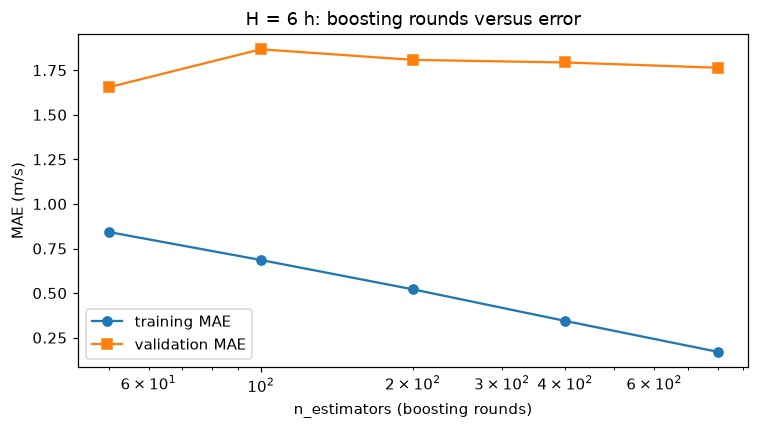

If the validation curve has flattened while the training curve keeps falling,
every extra round is buying overfitting rather than skill. That flattening point
is the operational answer to "how many trees do I need?" - and it is a much
better justification than ‘the default is 100’.


In [9]:
# How many boosting rounds are actually useful? Validation error versus n_estimators.
D = DATA[6]
rounds = [50, 100, 200, 400, 800]
curve = []
for n in rounds:
    if HAS_LGBM:
        m = lightgbm.LGBMRegressor(n_estimators=n, learning_rate=0.05, num_leaves=31,
                                   random_state=SEED, n_jobs=N_JOBS, verbose=-1)
    elif HAS_XGB:
        m = xgboost.XGBRegressor(n_estimators=n, learning_rate=0.05, max_depth=5,
                                 random_state=SEED, n_jobs=N_JOBS, verbosity=0)
    else:
        from sklearn.ensemble import GradientBoostingRegressor
        m = GradientBoostingRegressor(n_estimators=n, learning_rate=0.05, max_depth=3, random_state=SEED)
    m.fit(D['X_train'], D['y_train'])
    curve.append({'n_estimators': n,
                  'train_MAE': metrics(D['y_train'], m.predict(D['X_train']))['MAE'],
                  'val_MAE': metrics(D['y_val'], m.predict(D['X_val']))['MAE']})
    del m
curve = pd.DataFrame(curve)
print(curve.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curve['n_estimators'], curve['train_MAE'], marker='o', label='training MAE')
ax.plot(curve['n_estimators'], curve['val_MAE'], marker='s', label='validation MAE')
ax.set_xscale('log')
ax.set_xlabel('n_estimators (boosting rounds)')
ax.set_ylabel('MAE (m/s)')
ax.set_title('H = 6 h: boosting rounds versus error')
ax.legend()
plt.tight_layout()
plt.show()

print('If the validation curve has flattened while the training curve keeps falling,')
print('every extra round is buying overfitting rather than skill. That flattening point')
print('is the operational answer to "how many trees do I need?" - and it is a much')
print('better justification than ‘the default is 100’.')

---

## 7. How to read this session's results

Answer these in your own notebook, with the numbers in front of you:

1. **Did tuning help?** Compare `Boosting (default)` with `Boosting (tuned)`. If the improvement is smaller than the fold-to-fold spread, the honest conclusion is *the tuning did not produce a distinguishable improvement*.
2. **Did the ensemble beat the random forest everywhere?** If not, at which horizons does the forest hold up - and is the difference inside the noise?
3. **Did it beat the diurnal climatology?** At 24 h this is the real test. A one-line physical baseline that survives contact with a tuned ensemble is an important scientific statement.
4. **What did it cost?** Compare `fit_s`. If a tuned ensemble is 20 times slower for a 2 % MAE gain, an operational forecast office might still prefer the forest. Cost belongs in the discussion, not in a footnote.
5. **Is the tuned configuration physically sensible?** A very deep tree (`max_depth=8` with `learning_rate=0.2` and no subsampling) usually signals an over-fit search rather than a better model.

### What tuning cannot fix

- **Extrapolation.** No boosted tree can forecast a wind speed above the maximum it saw in training. Filter your predictions at the physical maximum and report the limitation.
- **Seasonal drift.** Our validation block is a different season from the training block; tuning cannot repair a distribution shift.
- **Missing physics.** If the station record contains no variable that carries the signal (for example a large-scale pressure gradient from a reanalysis), no hyper-parameter will invent it. Session 5 returns to this point.

---

## 8. Common pitfalls

**Pitfall 1 - `cross_val_score(model, X, y, cv=5)`.**  
The default `cv=5` is `KFold(shuffle=False)`, which at least keeps the order, but it has **no gap** and it trains on data that comes *after* the validation fold. Use `TimeSeriesSplit(n_splits=k, gap=H)` for time series, and always inside the training block only.

**Pitfall 2 - tuning on the validation block and reporting the tuned validation score.**  
The score becomes a selection criterion, not an independent measurement. Keep a test block.

**Pitfall 3 - an exhaustive grid over ten hyper-parameters.**  
It is exponential, mostly irrelevant, and it multiplies your selection leakage. Randomise, bound sensibly, and prefer log-uniform sampling for rates.

**Pitfall 4 - letting the search refit on the validation data.**  
`RandomizedSearchCV(..., refit=True)` refits the best candidate on the data you passed it: pass the **training block only**.

**Pitfall 5 - forgetting that boosting has its own randomness.**  
Seeds for `subsample`, `colsample` and the search must be fixed, or your results will not reproduce.

**Pitfall 6 - reporting a difference smaller than the fold spread.**  
A 0.02 m/s improvement with a 0.15 m/s fold spread is not a result. This is the most common over-claim in student projects.

**Pitfall 7 - memory.**  
Boosting with many threads on a 8 GB laptop can exhaust RAM. Keep `n_jobs` modest (2 here), use `colsample_bytree` below 1.0, and do not keep every fitted model in memory - we keep only predictions.

**Pitfall 8 - default hyper-parameters treated as neutral.**  
Defaults are tuned for typical tabular data, not for your variable, your season or your horizon. Tuning is not optional here; it is how you find out whether the defaults were fine.

---

## 9. AI-assisted workflow

### 9.1 Prompts for this session

| Goal | Prompt |
|---|---|
| understand the method | 'Explain gradient boosting to a geoscientist who knows regression trees, in 200 words, without equations, using the wind-forecasting example.' |
| set a sensible search space | 'For a 6,000-row tabular regression problem with 70 features and a strongly seasonal target, propose a randomised search space for LightGBM with 8 candidates. Justify each range and warn me about the parameters that mostly duplicate each other.' |
| build the CV correctly | 'Write a cross-validation loop for hourly time-series data with a 24-hour forecast horizon. The gaps must prevent any training target window from overlapping a validation row. Show the fold boundaries as dates and explain each line.' |
| interrogate a result | 'My tuned model improves MAE by 0.02 m/s over the default, but the fold-to-fold standard deviation is 0.15 m/s. Write the three-sentence conclusion a reviewer would accept.' |

### 9.2 Debugging prompts

```
My RandomizedSearchCV scores are all around -2500 and my manually computed MAE is
1.6 m/s. What is going on? Show how to convert neg_mean_absolute_error into MAE and
list the other sklearn scorer sign conventions that confuse people.
```

This is the single most common confusion with `RandomizedSearchCV`: **all sklearn scorers are 'greater is better'**, so regression errors are returned negated.

### 9.3 Code-review prompt

```
Review this tuning code as a strict reviewer for a geoscience journal.
Flag, with the exact line: (1) any use of data outside the training block,
(2) any fold without a purge gap, (3) selection leakage through repeated
validation looking, (4) missing seeds, (5) any conclusion not supported by
the reported dispersion. Do not rewrite the code.
```

### 9.4 Validation checklist

1. **Fold geometry printed.** Every tuning run should print per-fold row counts, dates and gaps. Do it once and paste the table into your report.
2. **Sign conventions.** The search reports negative MAE; convert before you interpret or plot.
3. **Selection leakage stated.** How many configurations did you compare, and on what data?
4. **Spread reported.** Per-fold mean and standard deviation, always.
5. **Cost reported.** Fit seconds per model and horizon.
6. **Reproducibility re-run.** Re-running the search with the same seed must give the same best parameters. If it does not, a seed is missing (often in the sampler or in the model's `subsample`).

### 9.5 Exercise

Ask an LLM to 'write a hyper-parameter tuning script for XGBoost on time-series data'. Check the fold generator it uses. In many answers you will find `KFold(shuffle=True)`, `cross_val_score` without a gap, or a search that includes the validation rows. Fix it, then write one paragraph explaining to a colleague why the original version would have produced a flattering, wrong number.

---

## 10. Exercises

### Level 1 - understanding

1. State the difference between bagging and boosting in two sentences, without naming a single library.
2. What does the `gap` argument of `TimeSeriesSplit` protect against?
3. Why does `RandomizedSearchCV` report negative MAE?
4. Give one hyper-parameter that mainly controls variance and one that mainly controls bias.

### Level 2 - implementation

5. Run the search with `H_TUNE = 6` instead of 24 and compare the winning configurations. Do the two horizons prefer different complexity?
6. Add `reg_alpha` (L1) to the search space and see whether it enters the top candidates.
7. Replace `RandomizedSearchCV` with a manual loop over five named configurations, using the same folds. Compare the winner with the random search winner.
8. Add a `HistGradientBoostingRegressor` (scikit-learn) to the comparison. It is fast and often competitive - a legitimate alternative when XGBoost and LightGBM are unavailable.
9. Use `staged_predict` (sklearn) or `evals_result` (LightGBM) to plot the validation curve during training rather than refitting per `n_estimators`.

### Level 3 - reasoning

10. The tuned model improves the fold score but not the official validation score. List three explanations, and say which one you can test.
11. Is it legitimate to tune separately for each horizon? Argue both sides, with the selection-leakage budget in mind.
12. You have a 20-minute compute budget per horizon in an operational setting. Which hyper-parameters would you spend the budget on, and which would you fix?
13. Your best model at 24 h is a random forest, not a boosted ensemble. Write the honest result sentence and explain why it is still a useful finding.

### Level 4 - application (project work)

14. **Deliver a tuned model.** Produce, in a markdown cell: the search space, the number of candidates, the fold geometry table, the top-5 candidates with their fold spread, the tuned configuration, the validation MAE at all four horizons with its skill versus each baseline, and the fit cost. This is the tuning subsection of your report.
15. **Write the negative-result paragraph.** In three or four sentences, explain what you would report if tuning produced no reliable improvement. Reviewers value this paragraph; it demonstrates that you can distinguish a result from noise.

---

## 11. Reproducibility notes

- **One source:** `data/raw/abali.xlsx`, read-only, cleaned in memory.
- **Seeds:** `SEED = 42` for the model, the search sampler and the feature selection. A re-run must reproduce the winning parameters exactly.
- **Toggles to report:** `QUICK_MODE`, `N_TREES`, `N_JOBS`, `N_SEARCH_ITER`, `CV_SPLITS`, and every value in the search space.
- **Library versions matter for boosting.** Print and record them: XGBoost and LightGBM change their defaults between major versions, and an unreported version makes a tuning result irreproducible.
- **Fold geometry is data, not code.** Print the fold boundaries and keep them in the report; they are the definition of your validation scheme.
- **The test block is still untouched.** Verify by grepping your notebook for `y_test` before Session 7.
- **Nothing is written to disk.** Predictions and metrics stay in memory.

---

## 12. Key takeaways

1. Boosting reduces bias by fitting residuals sequentially; bagging reduces variance by averaging independent trees. Both are ensembles of trees, and neither can extrapolate.
2. Cross-validation for time series means expanding windows **with a purge gap**, inside the training block only.
3. Randomised search with a physically motivated range beats an exhaustive grid on cost, and usually on honesty too, because fewer looks at the data means less selection leakage.
4. The tuned configuration must be verified on the official validation block, and every comparison must be checked against the fold-to-fold spread.
5. Beating persistence is not enough at long horizons: the diurnal climatology is the demanding benchmark.
6. Report cost, dispersion and negative results - they are part of the scientific claim, not decoration.

In [10]:
# ===========================================================================
# FINAL VALIDATION CELL - run last, in every notebook
# ===========================================================================
WARNINGS = []
if not HAS_XGB:
    WARNINGS.append('xgboost not installed: boosting is provided by another library or by sklearn GradientBoostingRegressor')
if not HAS_LGBM:
    WARNINGS.append('lightgbm not installed: boosting is provided by XGBoost or by sklearn GradientBoostingRegressor')
if QUICK_MODE:
    WARNINGS.append('QUICK_MODE=True: search limited to {} candidates and {} CV folds'.format(N_SEARCH_ITER, CV_SPLITS))
WARNINGS.append('hyper-parameters were tuned at H = {} h and reused for the other horizons'.format(H_TUNE))
WARNINGS.append('candidate ranking at H = {} h: mean fold MAE {:.4f} +- {:.4f} (1 std) - do not claim differences smaller than this'.format(
    H_TUNE, -search.best_score_, float(results.loc[results['mae'].idxmin(), 'std_test_score'])))

manifest = {
    'notebook': '04_ensemble_models_and_tuning_abali.ipynb',
    'session': 'Session 4 - ensemble models and hyper-parameter optimisation',
    'dataset_used': RAW_PATH + ' (Abali station, hourly, cleaned in memory)',
    'target_variable': 'wind_speed_ms at T + H (m/s), direct multi-horizon',
    'forecast_horizons_hours': HORIZONS,
    'models_used': ['Persistence', 'Diurnal climatology', 'Random Forest',
                    'Boosting (default)', 'Boosting (tuned)'],
    'boosting_library': MODEL_TAG,
    'best_params': {k: (float(v) if isinstance(v, (int, float, np.floating, np.integer)) else v) for k, v in BEST_PARAMS.items()},
    'validation_scheme': 'TimeSeriesSplit(n_splits={}, gap=H) inside the training block'.format(CV_SPLITS),
    'metrics_used': ['MAE', 'RMSE', 'R2', 'skill_vs_persistence', 'gain_vs_diurnal_climatology'],
    'validation_MAE': {str(H): {m: float(v) for m, v in SCOREBOARD[SCOREBOARD['horizon_h'] == H].set_index('model')['val_MAE'].items()} for H in HORIZONS},
    'test_block_touched': False,
    'files_written': 'none (all work in memory)',
    'random_seed': SEED,
    'warnings': WARNINGS,
}
print(json.dumps(manifest, indent=2, default=str))

{
  "notebook": "04_ensemble_models_and_tuning_abali.ipynb",
  "session": "Session 4 - ensemble models and hyper-parameter optimisation",
  "dataset_used": "../../data/raw/abali.xlsx (Abali station, hourly, cleaned in memory)",
  "target_variable": "wind_speed_ms at T + H (m/s), direct multi-horizon",
  "forecast_horizons_hours": [
    3,
    6,
    12,
    24
  ],
  "models_used": [
    "Persistence",
    "Diurnal climatology",
    "Random Forest",
    "Boosting (default)",
    "Boosting (tuned)"
  ],
  "boosting_library": "LightGBM",
  "best_params": {
    "subsample": 0.6,
    "reg_lambda": 0.0,
    "num_leaves": 31.0,
    "n_estimators": 800.0,
    "min_child_samples": 20.0,
    "learning_rate": 0.02,
    "colsample_bytree": 1.0
  },
  "validation_scheme": "TimeSeriesSplit(n_splits=3, gap=H) inside the training block",
  "metrics_used": [
    "MAE",
    "RMSE",
    "R2",
    "skill_vs_persistence",
    "gain_vs_diurnal_climatology"
  ],
  "validation_MAE": {
    "3": {
      "Rando

---

### What comes next

In **Session 5** the horizon itself becomes the subject:

- why a 24-hour-ahead forecast is not simply 'a 3-hour forecast applied longer';
- **walk-forward validation** - the closest thing to how an operational forecast is really verified;
- multi-step and multi-horizon evaluation on 3, 6, 12 and 24 h, with skill curves against persistence and the diurnal climatology;
- the mistakes that specifically break weather-forecasting ML: leaking the target through windows, ignoring seasonality in the verification, and reporting a single average score for all conditions.

Before then, finish exercises 5, 10 and 15 - exercise 15 in particular will be reused in your final report.